# Research study: time to benefit

**Question:** How long does budget phasing need to run before elasticity uncertainty meaningfully reduces?

The fan charts in notebook 02 show that one year of phasing barely narrows the elasticity bands when the model is fit on four years of correlated history. This notebook quantifies that precisely:

- **Section 1** — plan period sweep: vary plan length from 4 → 260 weeks, track band width (90th–10th pct of elasticity estimates)
- **Section 2** — correlation sensitivity: does baseline spend correlation change how quickly phasing helps?
- **Section 3** — weighting sensitivity: how aggressively do you need to upweight recent phased data?

The output metric throughout is **band width** (90th–10th pct of estimated elasticities across noise seeds), reported per channel and as a max across channels. Wider band = more unreliable model.

All simulations use a fixed 4-year correlated history (208 weeks). Only the plan period varies.

In [91]:
FAST_MODE = False  # set False for publication-quality runs (slower)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from how_wrong_is_your_mmm import CollinearityDiagnostic
from how_wrong_is_your_mmm._dgp import simulate_spend
from how_wrong_is_your_mmm._phaser import (
    _compute_weights,
    _generate_phased_schedule,
    _get_month_labels,
)

N_SIMS = 10 if FAST_MODE else 50
N_PHASING_SEEDS = 1 if FAST_MODE else 5

print(f"FAST_MODE={FAST_MODE}  |  N_SIMS={N_SIMS}  |  N_PHASING_SEEDS={N_PHASING_SEEDS}")

FAST_MODE=False  |  N_SIMS=50  |  N_PHASING_SEEDS=5


In [92]:
# ── Fixed params ─────────────────────────────────────────────────────────────
TRUE_ELASTICITIES = {"tv": 0.3, "meta": 0.5, "search": 0.4}
N_HISTORY = 208          # 4 years of weekly data
CORRELATION = 0.7        # realistic inter-channel correlation
PLAN_WEIGHT = 5.0        # used only in Section 3 (weighting sensitivity)
# Sections 1 & 2 use uniform weighting — the optimal scheme found in Section 3
MAX_WEEKLY_DEV_PCT = 40.0

COLORS = {"tv": "steelblue", "meta": "coral", "search": "mediumseagreen"}

# ── Fixed history (same throughout all sections) ──────────────────────────────
history = simulate_spend(n_obs=N_HISTORY, correlation=CORRELATION, seed=42)
history.index = pd.date_range("2020-01-06", periods=N_HISTORY, freq="W-MON")

# ── Band width helper ─────────────────────────────────────────────────────────
def band_width(diag: CollinearityDiagnostic) -> pd.Series:
    """Return 90th–10th pct band width per channel from a fitted diagnostic."""
    return (
        diag.results_
        .groupby("channel")["estimated_elasticity"]
        .apply(lambda x: float(x.quantile(0.9) - x.quantile(0.1)))
    )

# ── Baseline: history only, no new data ──────────────────────────────────────
baseline_diag = CollinearityDiagnostic(
    spend_df=history,
    true_elasticities=TRUE_ELASTICITIES,
)
baseline_diag.fit(n_sims=N_SIMS)
baseline_bw = band_width(baseline_diag)
print("Baseline band widths (history only):")
print(baseline_bw.round(3))

Baseline band widths (history only):
channel
meta      0.333
search    0.460
tv        0.231
Name: estimated_elasticity, dtype: float64


## Section 1 — Plan period sweep

Fix the 4-year history. Add a plan period of increasing length (4 → 260 weeks) at max phasing amplitude (α=1). Track how band width changes as more de-correlated data accumulates.

Three series per channel:
- **History only** (dashed) — current state, no new data
- **Unphased** (dotted) — new data added but not phased; isolates the "more data" effect
- **Max phased** (solid) — new data added with max independent variation

The gap between unphased and phased is the value of phasing itself.

In [93]:
plan_lengths = (
    [4, 13, 26, 52, 104, 208]
    if FAST_MODE
    else [4, 8, 13, 26, 39, 52, 78, 104, 130, 156, 182, 208, 260]
)

records = []

for n_plan in plan_lengths:
    plan_start = history.index[-1] + pd.Timedelta(weeks=1)
    plan_raw = simulate_spend(n_obs=n_plan, correlation=CORRELATION, seed=99)
    plan_raw.index = pd.date_range(plan_start, periods=n_plan, freq="W-MON")
    month_labels = _get_month_labels(plan_raw)

    weights = _compute_weights(
        n_history=N_HISTORY,
        n_plan=n_plan,
        weighting="uniform",
        plan_weight=1.0,
        half_life=52,
    )

    # ── Unphased: just append original plan (alpha=0) ──────────────────────
    combined_unphased = pd.concat([history, plan_raw])
    diag_unphased = CollinearityDiagnostic(
        spend_df=combined_unphased,
        true_elasticities=TRUE_ELASTICITIES,
        weights=weights,
    )
    diag_unphased.fit(n_sims=N_SIMS)
    bw_unphased = band_width(diag_unphased)

    # ── Max phased: alpha=1, averaged over N_PHASING_SEEDS ────────────────
    seed_bws = []
    for ps in range(N_PHASING_SEEDS):
        phased = _generate_phased_schedule(
            plan_raw, month_labels,
            alpha=1.0,
            max_weekly_deviation_pct=MAX_WEEKLY_DEV_PCT,
            seed=ps,
        )
        combined_phased = pd.concat([history, phased])
        diag_phased = CollinearityDiagnostic(
            spend_df=combined_phased,
            true_elasticities=TRUE_ELASTICITIES,
            weights=weights,
        )
        diag_phased.fit(n_sims=N_SIMS)
        seed_bws.append(band_width(diag_phased))
    bw_phased = pd.concat(seed_bws, axis=1).mean(axis=1)

    rec = {"plan_weeks": n_plan}
    for ch in TRUE_ELASTICITIES:
        rec[f"{ch}_unphased"] = bw_unphased[ch]
        rec[f"{ch}_phased"] = bw_phased[ch]
    rec["max_unphased"] = bw_unphased.max()
    rec["max_phased"] = bw_phased.max()
    records.append(rec)
    print(f"n_plan={n_plan:>3}w  |  max_bw unphased={rec['max_unphased']:.3f}  phased={rec['max_phased']:.3f}")

df_sweep = pd.DataFrame(records)

n_plan=  4w  |  max_bw unphased=0.442  phased=0.429
n_plan=  8w  |  max_bw unphased=0.483  phased=0.425
n_plan= 13w  |  max_bw unphased=0.453  phased=0.405
n_plan= 26w  |  max_bw unphased=0.423  phased=0.380
n_plan= 39w  |  max_bw unphased=0.408  phased=0.297
n_plan= 52w  |  max_bw unphased=0.403  phased=0.323
n_plan= 78w  |  max_bw unphased=0.334  phased=0.270
n_plan=104w  |  max_bw unphased=0.381  phased=0.241
n_plan=130w  |  max_bw unphased=0.274  phased=0.206
n_plan=156w  |  max_bw unphased=0.349  phased=0.207
n_plan=182w  |  max_bw unphased=0.270  phased=0.190
n_plan=208w  |  max_bw unphased=0.342  phased=0.210
n_plan=260w  |  max_bw unphased=0.245  phased=0.169


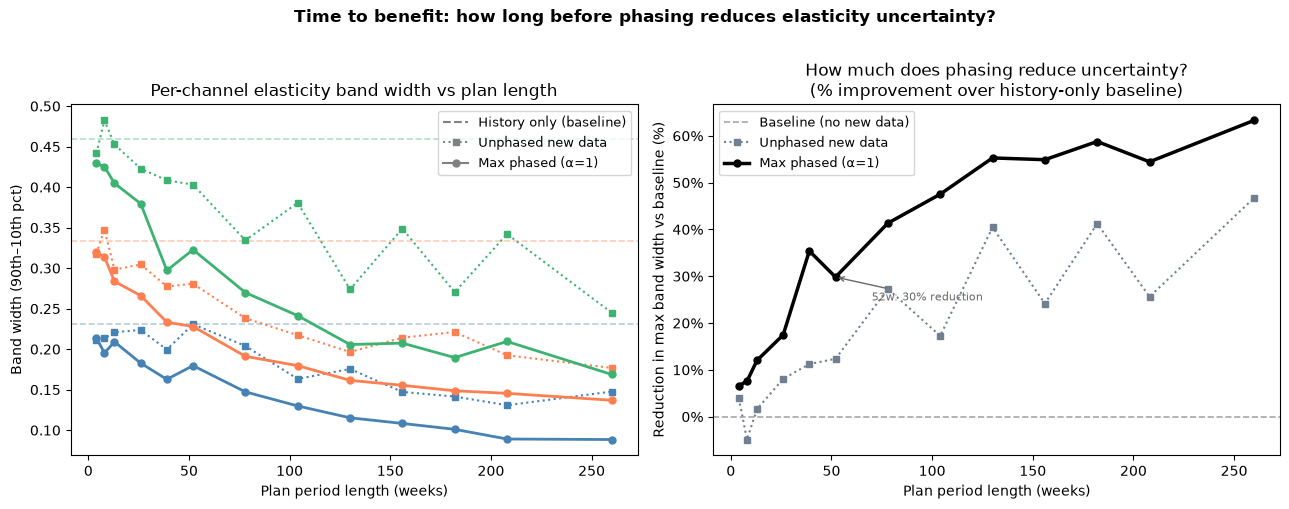


── Key findings ─────────────────────────────────────────────────────
Baseline max band width (history only): 0.460
  Plan =   4w  |  max band width = 0.429  |  reduction = +6.7%
  Plan =   8w  |  max band width = 0.425  |  reduction = +7.6%
  Plan =  13w  |  max band width = 0.405  |  reduction = +12.0%
  Plan =  26w  |  max band width = 0.380  |  reduction = +17.5%
  Plan =  39w  |  max band width = 0.297  |  reduction = +35.4%
  Plan =  52w  |  max band width = 0.323  |  reduction = +29.8%
  Plan =  78w  |  max band width = 0.270  |  reduction = +41.3%
  Plan = 104w  |  max band width = 0.241  |  reduction = +47.5%
  Plan = 130w  |  max band width = 0.206  |  reduction = +55.3%
  Plan = 156w  |  max band width = 0.207  |  reduction = +54.9%
  Plan = 182w  |  max band width = 0.190  |  reduction = +58.8%
  Plan = 208w  |  max band width = 0.210  |  reduction = +54.5%
  Plan = 260w  |  max band width = 0.169  |  reduction = +63.3%

→ First plan length with ≥30% reduction: 39 weeks (0

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: per-channel absolute band width (unchanged)
ax = axes[0]
for ch, color in COLORS.items():
    ax.axhline(baseline_bw[ch], color=color, linestyle="--", alpha=0.4, linewidth=1.2)
    ax.plot(df_sweep["plan_weeks"], df_sweep[f"{ch}_unphased"],
            color=color, linestyle=":", linewidth=1.5, marker="s", markersize=4)
    ax.plot(df_sweep["plan_weeks"], df_sweep[f"{ch}_phased"],
            color=color, linestyle="-", linewidth=2, marker="o", markersize=5,
            label=ch.upper())

ax.set_xlabel("Plan period length (weeks)")
ax.set_ylabel("Band width (90th\u201310th pct)")
ax.set_title("Per-channel elasticity band width vs plan length")

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="gray", linestyle="--", label="History only (baseline)"),
    Line2D([0], [0], color="gray", linestyle=":", marker="s", markersize=4, label="Unphased new data"),
    Line2D([0], [0], color="gray", linestyle="-", marker="o", markersize=5, label="Max phased (\u03b1=1)"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=9)

# Right: % reduction in max band width vs baseline (history only)
ax2 = axes[1]
baseline_max = baseline_bw.max()
reduction_pct = (baseline_max - df_sweep["max_phased"]) / baseline_max * 100
unphased_reduction_pct = (baseline_max - df_sweep["max_unphased"]) / baseline_max * 100

ax2.axhline(0, color="black", linestyle="--", alpha=0.35, linewidth=1.2, label="Baseline (no new data)")
ax2.plot(df_sweep["plan_weeks"], unphased_reduction_pct,
         color="slategray", linestyle=":", linewidth=1.5, marker="s", markersize=4,
         label="Unphased new data")
ax2.plot(df_sweep["plan_weeks"], reduction_pct,
         color="black", linestyle="-", linewidth=2.5, marker="o", markersize=5,
         label="Max phased (\u03b1=1)")

# Annotate 52-week mark
if 52 in df_sweep["plan_weeks"].values:
    r_52 = float(reduction_pct[df_sweep["plan_weeks"] == 52].iloc[0])
    ax2.annotate(f"52w: {r_52:.0f}% reduction",
                 xy=(52, r_52), xytext=(70, r_52 - 5),
                 fontsize=8, arrowprops=dict(arrowstyle="->", color="dimgray"), color="dimgray")

ax2.set_xlabel("Plan period length (weeks)")
ax2.set_ylabel("Reduction in max band width vs baseline (%)")
ax2.set_title("How much does phasing reduce uncertainty?\n(% improvement over history-only baseline)")
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))

plt.suptitle("Time to benefit: how long before phasing reduces elasticity uncertainty?",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── Headline numbers ──────────────────────────────────────────────────────────
print("\n── Key findings ─────────────────────────────────────────────────────")
print(f"Baseline max band width (history only): {baseline_max:.3f}")
for _, row in df_sweep.iterrows():
    r = (baseline_max - row['max_phased']) / baseline_max * 100
    print(f"  Plan = {int(row['plan_weeks']):>3}w  |  max band width = {row['max_phased']:.3f}  |  reduction = {r:+.1f}%")

# Find elbow: first plan length where improvement exceeds 30%
threshold = 30.0
hits = df_sweep[reduction_pct >= threshold]
if not hits.empty:
    elbow = int(hits.iloc[0]["plan_weeks"])
    print(f"\n\u2192 First plan length with \u226530% reduction: {elbow} weeks ({elbow/52:.1f} years)")
else:
    print(f"\n\u2192 Max reduction does not reach 30% in this sweep")

## Section 2 — Correlation sensitivity

Fix plan length at 52 weeks (1 year). Vary baseline spend correlation from 0.3 → 0.9. How much does starting correlation affect the benefit from phasing?

**Expected finding:** higher baseline correlation → wider starting band → phasing provides more absolute reduction, but the relative improvement may be similar across correlation levels.

In [95]:
correlations = [0.3, 0.5, 0.7, 0.9]
PLAN_WEEKS_S2 = 52

corr_records = []

for corr in correlations:
    # Generate history at this correlation level
    hist = simulate_spend(n_obs=N_HISTORY, correlation=corr, seed=42)
    hist.index = pd.date_range("2020-01-06", periods=N_HISTORY, freq="W-MON")

    plan_start = hist.index[-1] + pd.Timedelta(weeks=1)
    plan_raw = simulate_spend(n_obs=PLAN_WEEKS_S2, correlation=corr, seed=99)
    plan_raw.index = pd.date_range(plan_start, periods=PLAN_WEEKS_S2, freq="W-MON")
    month_labels = _get_month_labels(plan_raw)

    weights = _compute_weights(
        n_history=N_HISTORY, n_plan=PLAN_WEEKS_S2,
        weighting="uniform", plan_weight=1.0, half_life=52,
    )

    # Baseline (history only)
    d_base = CollinearityDiagnostic(spend_df=hist, true_elasticities=TRUE_ELASTICITIES)
    d_base.fit(n_sims=N_SIMS)
    bw_base = band_width(d_base)

    # Max phased (averaged)
    seed_bws = []
    for ps in range(N_PHASING_SEEDS):
        phased = _generate_phased_schedule(
            plan_raw, month_labels, alpha=1.0,
            max_weekly_deviation_pct=MAX_WEEKLY_DEV_PCT, seed=ps,
        )
        combined = pd.concat([hist, phased])
        d = CollinearityDiagnostic(spend_df=combined, true_elasticities=TRUE_ELASTICITIES, weights=weights)
        d.fit(n_sims=N_SIMS)
        seed_bws.append(band_width(d))
    bw_phased = pd.concat(seed_bws, axis=1).mean(axis=1)

    rec = {"correlation": corr}
    for ch in TRUE_ELASTICITIES:
        rec[f"{ch}_base"] = bw_base[ch]
        rec[f"{ch}_phased"] = bw_phased[ch]
    rec["max_base"] = bw_base.max()
    rec["max_phased"] = bw_phased.max()
    rec["max_reduction_pct"] = 100 * (bw_base.max() - bw_phased.max()) / bw_base.max()
    corr_records.append(rec)
    print(f"corr={corr}  |  max_bw base={rec['max_base']:.3f}  phased={rec['max_phased']:.3f}  reduction={rec['max_reduction_pct']:.1f}%")

df_corr = pd.DataFrame(corr_records)

corr=0.3  |  max_bw base=0.171  phased=0.168  reduction=1.9%
corr=0.5  |  max_bw base=0.281  phased=0.236  reduction=15.9%
corr=0.7  |  max_bw base=0.460  phased=0.323  reduction=29.8%
corr=0.9  |  max_bw base=0.837  phased=0.408  reduction=51.3%


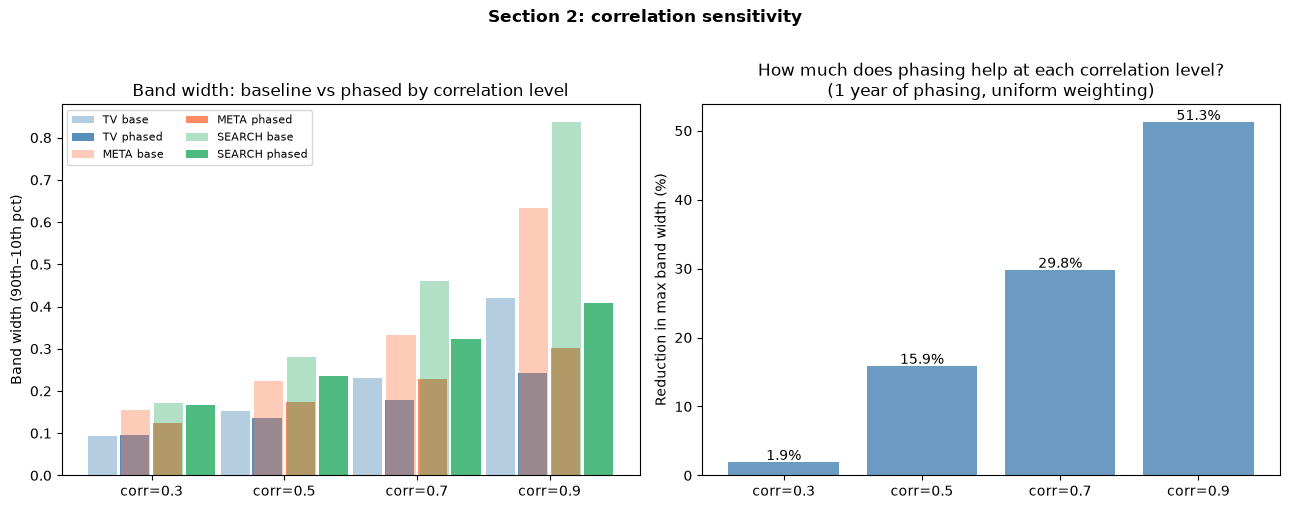

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(correlations))
width = 0.35

# Left: absolute band widths grouped by correlation
ax = axes[0]
for i, ch in enumerate(TRUE_ELASTICITIES):
    offset = (i - 1) * 0.25
    ax.bar(x + offset - 0.12, df_corr[f"{ch}_base"], 0.22,
           color=COLORS[ch], alpha=0.4, label=f"{ch.upper()} base")
    ax.bar(x + offset + 0.12, df_corr[f"{ch}_phased"], 0.22,
           color=COLORS[ch], alpha=0.9, label=f"{ch.upper()} phased")

ax.set_xticks(x)
ax.set_xticklabels([f"corr={c}" for c in correlations])
ax.set_ylabel("Band width (90th–10th pct)")
ax.set_title("Band width: baseline vs phased by correlation level")
ax.legend(fontsize=8, ncol=2)

# Right: % reduction in max band width
ax2 = axes[1]
ax2.bar(x, df_corr["max_reduction_pct"], color="steelblue", alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels([f"corr={c}" for c in correlations])
ax2.set_ylabel("Reduction in max band width (%)")
ax2.set_title("How much does phasing help at each correlation level?\n(1 year of phasing, uniform weighting)")
for i, v in enumerate(df_corr["max_reduction_pct"]):
    ax2.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=10)

plt.suptitle("Section 2: correlation sensitivity", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Sensitivity: how does benefit scale with correlation?

The coarse sweep (Section 2) showed phasing helps at all tested correlation levels under uniform weighting. This cell runs a finer grid (0.40 → 0.75) to see how the benefit scales.

**Finding: there is no crossover.** Phasing is beneficial at every correlation level, with the benefit scaling monotonically with correlation. All bars are green.

corr=0.4  |  base=0.221  phased=0.201  reduction=+9.0%
corr=0.5  |  base=0.281  phased=0.236  reduction=+15.9%
corr=0.55  |  base=0.316  phased=0.256  reduction=+18.9%
corr=0.6  |  base=0.357  phased=0.279  reduction=+21.7%
corr=0.65  |  base=0.404  phased=0.301  reduction=+25.4%
corr=0.7  |  base=0.460  phased=0.323  reduction=+29.8%
corr=0.75  |  base=0.529  phased=0.342  reduction=+35.3%


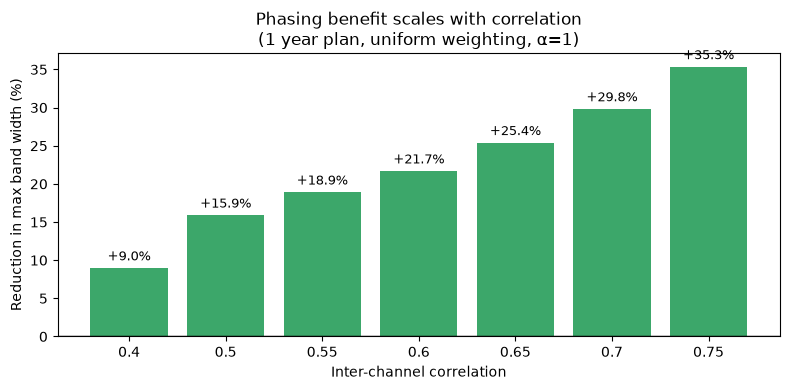


→ Phasing is beneficial at all correlation levels tested.
Benefit scales from 9.0% (corr=0.4) to 35.3% (corr=0.75)


In [97]:
correlations_fine = [0.40, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75]

fine_records = []
for corr in correlations_fine:
    hist = simulate_spend(n_obs=N_HISTORY, correlation=corr, seed=42)
    hist.index = pd.date_range("2020-01-06", periods=N_HISTORY, freq="W-MON")

    plan_start = hist.index[-1] + pd.Timedelta(weeks=1)
    plan_raw = simulate_spend(n_obs=PLAN_WEEKS_S2, correlation=corr, seed=99)
    plan_raw.index = pd.date_range(plan_start, periods=PLAN_WEEKS_S2, freq="W-MON")
    month_labels = _get_month_labels(plan_raw)

    weights = _compute_weights(
        n_history=N_HISTORY, n_plan=PLAN_WEEKS_S2,
        weighting="uniform", plan_weight=1.0, half_life=52,
    )

    # Baseline
    d_base = CollinearityDiagnostic(spend_df=hist, true_elasticities=TRUE_ELASTICITIES)
    d_base.fit(n_sims=N_SIMS)
    bw_base = band_width(d_base).max()

    # Max phased
    seed_bws = []
    for ps in range(N_PHASING_SEEDS):
        phased = _generate_phased_schedule(
            plan_raw, month_labels, alpha=1.0,
            max_weekly_deviation_pct=MAX_WEEKLY_DEV_PCT, seed=ps,
        )
        combined = pd.concat([hist, phased])
        d = CollinearityDiagnostic(spend_df=combined, true_elasticities=TRUE_ELASTICITIES, weights=weights)
        d.fit(n_sims=N_SIMS)
        seed_bws.append(band_width(d).max())
    bw_phased = float(np.mean(seed_bws))

    reduction = (bw_base - bw_phased) / bw_base * 100
    fine_records.append({"correlation": corr, "base": bw_base, "phased": bw_phased, "reduction_pct": reduction})
    print(f"corr={corr}  |  base={bw_base:.3f}  phased={bw_phased:.3f}  reduction={reduction:+.1f}%")

df_fine = pd.DataFrame(fine_records)

fig, ax = plt.subplots(figsize=(8, 4))
colors_bar = ["#1a9850"] * len(df_fine)
bars = ax.bar([str(c) for c in df_fine["correlation"]], df_fine["reduction_pct"],
              color=colors_bar, alpha=0.85)
ax.axhline(0, color="black", linewidth=1)
for bar, v in zip(bars, df_fine["reduction_pct"]):
    ax.text(bar.get_x() + bar.get_width()/2, v + (1 if v >= 0 else -2.5),
            f"{v:+.1f}%", ha="center", fontsize=9)
ax.set_xlabel("Inter-channel correlation")
ax.set_ylabel("Reduction in max band width (%)")
ax.set_title("Phasing benefit scales with correlation\n(1 year plan, uniform weighting, \u03b1=1)")
plt.tight_layout()
plt.show()

print(f"\n\u2192 Phasing is beneficial at all correlation levels tested.")
print("Benefit scales from", f"{df_fine['reduction_pct'].min():.1f}% (corr={df_fine['correlation'].min()})", "to", f"{df_fine['reduction_pct'].max():.1f}% (corr={df_fine['correlation'].max()})")

## Section 3 — Weighting sensitivity

Fix plan length at 52 weeks and correlation at 0.7. Compares uniform, binary (plan_weight=5), and decay weighting schemes.

The plan_weight sweep is omitted — within binary weighting, lower is always better, which is just converging back to uniform. The meaningful question is which scheme to use, not how to tune binary.

In [98]:
PLAN_WEEKS_S3 = 52

plan_start = history.index[-1] + pd.Timedelta(weeks=1)
plan_raw_s3 = simulate_spend(n_obs=PLAN_WEEKS_S3, correlation=CORRELATION, seed=99)
plan_raw_s3.index = pd.date_range(plan_start, periods=PLAN_WEEKS_S3, freq="W-MON")
month_labels_s3 = _get_month_labels(plan_raw_s3)

# Pre-generate phased plans (averaged over seeds)
phased_plans = []
for ps in range(N_PHASING_SEEDS):
    phased_plans.append(_generate_phased_schedule(
        plan_raw_s3, month_labels_s3, alpha=1.0,
        max_weekly_deviation_pct=MAX_WEEKLY_DEV_PCT, seed=ps,
    ))

# Scheme comparison
scheme_records = []
for scheme in ["uniform", "binary", "decay"]:
    weights = _compute_weights(
        n_history=N_HISTORY, n_plan=PLAN_WEEKS_S3,
        weighting=scheme, plan_weight=5.0, half_life=52,
    )
    seed_bws = []
    for phased in phased_plans:
        combined = pd.concat([history, phased])
        d = CollinearityDiagnostic(spend_df=combined, true_elasticities=TRUE_ELASTICITIES, weights=weights)
        d.fit(n_sims=N_SIMS)
        seed_bws.append(band_width(d))
    bw_phased = pd.concat(seed_bws, axis=1).mean(axis=1)
    scheme_records.append({"scheme": scheme, "max_phased": bw_phased.max(),
                           **{ch: bw_phased[ch] for ch in TRUE_ELASTICITIES}})
    print(f"scheme={scheme:<8}  |  max_bw={bw_phased.max():.3f}")

df_scheme = pd.DataFrame(scheme_records)

scheme=uniform   |  max_bw=0.323
scheme=binary    |  max_bw=0.357
scheme=decay     |  max_bw=0.349


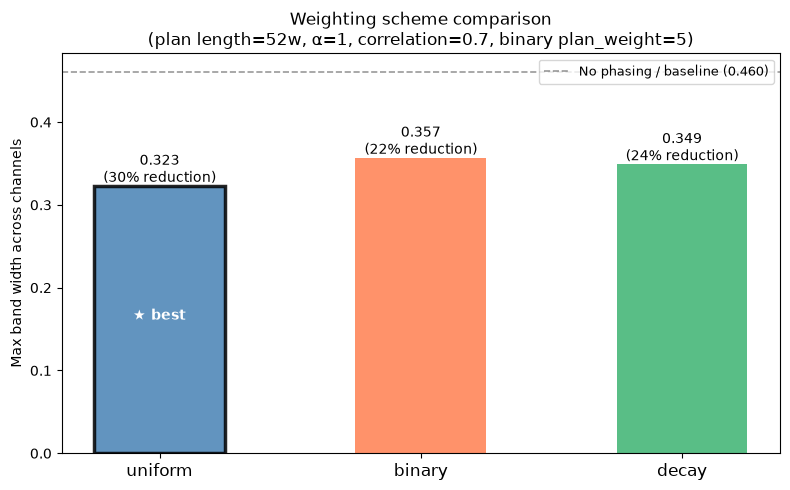


── Key findings ─────────────────────────────────────────────────────
Uniform weighting is best. Binary and decay upweight a small amount of phased
data against a large correlated history, amplifying noise rather than signal.
With 52/260 weeks of phased data (20%), all observations should count equally.

→ Recommended weighting scheme: uniform
   Implication: BudgetPhaser default should change from weighting='binary' to weighting='uniform'


In [99]:
fig, ax = plt.subplots(figsize=(8, 5))

scheme_colors = ["steelblue", "coral", "mediumseagreen"]
x = np.arange(len(df_scheme))
bars = ax.bar(x, df_scheme["max_phased"], color=scheme_colors, alpha=0.85, width=0.5)
ax.axhline(baseline_bw.max(), color="black", linestyle="--", alpha=0.4,
           linewidth=1.2, label=f"No phasing / baseline ({baseline_bw.max():.3f})")

ax.set_xticks(x)
ax.set_xticklabels(df_scheme["scheme"], fontsize=12)
ax.set_ylabel("Max band width across channels")
ax.set_title("Weighting scheme comparison\n(plan length=52w, α=1, correlation=0.7, binary plan_weight=5)")
ax.legend(fontsize=9)

for i, (v, bar) in enumerate(zip(df_scheme["max_phased"], bars)):
    reduction = (baseline_bw.max() - v) / baseline_bw.max() * 100
    ax.text(i, v + 0.005, f"{v:.3f}\n({reduction:.0f}% reduction)", ha="center", fontsize=10)
    if df_scheme.iloc[i]["scheme"] == "uniform":
        bar.set_edgecolor("black")
        bar.set_linewidth(2.5)
        ax.text(i, v / 2, "\u2605 best", ha="center", fontsize=10,
                color="white", fontweight="bold")

plt.tight_layout()
plt.show()

print("\n── Key findings ─────────────────────────────────────────────────────")
print("Uniform weighting is best. Binary and decay upweight a small amount of phased")
print("data against a large correlated history, amplifying noise rather than signal.")
print("With 52/260 weeks of phased data (20%), all observations should count equally.")
best_scheme = df_scheme.loc[df_scheme["max_phased"].idxmin(), "scheme"]
print(f"\n\u2192 Recommended weighting scheme: {best_scheme}")
print(f"   Implication: BudgetPhaser default should change from weighting='binary' to weighting='uniform'")

## Section 4 — Spend amplitude sensitivity

All previous sections fixed `max_weekly_deviation_pct=40` — the maximum allowed weekly channel variation within a month. This section asks:

1. **Part A** — at a fixed 1-year plan, does allowing more aggressive weekly deviation give more benefit? Sweep 10% → 100%.
2. **Part B** — does higher deviation shift the time-to-benefit curve left? Re-run the plan period sweep at three deviation levels (20%, 40%, 80%) on the same axes.

If the elbow shifts left at higher deviation, practitioners can hit the same benefit faster by accepting more weekly volatility. If it doesn't shift, time is the binding constraint regardless of how aggressively you phase.

### Part A — Deviation amplitude vs benefit (fixed plan length = 52 weeks)

In [100]:
deviations = (
    [10, 20, 40, 80, 100]
    if FAST_MODE
    else [10, 20, 30, 40, 60, 80, 100]
)
PLAN_WEEKS_S4 = 52

plan_start = history.index[-1] + pd.Timedelta(weeks=1)
plan_raw_s4 = simulate_spend(n_obs=PLAN_WEEKS_S4, correlation=CORRELATION, seed=99)
plan_raw_s4.index = pd.date_range(plan_start, periods=PLAN_WEEKS_S4, freq="W-MON")
month_labels_s4 = _get_month_labels(plan_raw_s4)

weights_s4 = _compute_weights(
    n_history=N_HISTORY, n_plan=PLAN_WEEKS_S4,
    weighting="uniform", plan_weight=1.0, half_life=52,
)

dev_records = []
for dev in deviations:
    seed_bws = []
    for ps in range(N_PHASING_SEEDS):
        phased = _generate_phased_schedule(
            plan_raw_s4, month_labels_s4,
            alpha=1.0,
            max_weekly_deviation_pct=dev,
            seed=ps,
        )
        combined = pd.concat([history, phased])
        d = CollinearityDiagnostic(
            spend_df=combined,
            true_elasticities=TRUE_ELASTICITIES,
            weights=weights_s4,
        )
        d.fit(n_sims=N_SIMS)
        seed_bws.append(band_width(d))
    bw = pd.concat(seed_bws, axis=1).mean(axis=1)
    reduction = (baseline_bw.max() - bw.max()) / baseline_bw.max() * 100
    dev_records.append({"dev_pct": dev, "max_bw": bw.max(), "reduction_pct": reduction,
                        **{ch: bw[ch] for ch in TRUE_ELASTICITIES}})
    print(f"dev={dev:>3}%  |  max_bw={bw.max():.3f}  reduction={reduction:+.1f}%")

df_dev = pd.DataFrame(dev_records)

dev= 10%  |  max_bw=0.420  reduction=+8.8%
dev= 20%  |  max_bw=0.388  reduction=+15.6%
dev= 30%  |  max_bw=0.354  reduction=+23.0%
dev= 40%  |  max_bw=0.323  reduction=+29.8%
dev= 60%  |  max_bw=0.257  reduction=+44.1%
dev= 80%  |  max_bw=0.214  reduction=+53.4%
dev=100%  |  max_bw=0.178  reduction=+61.2%


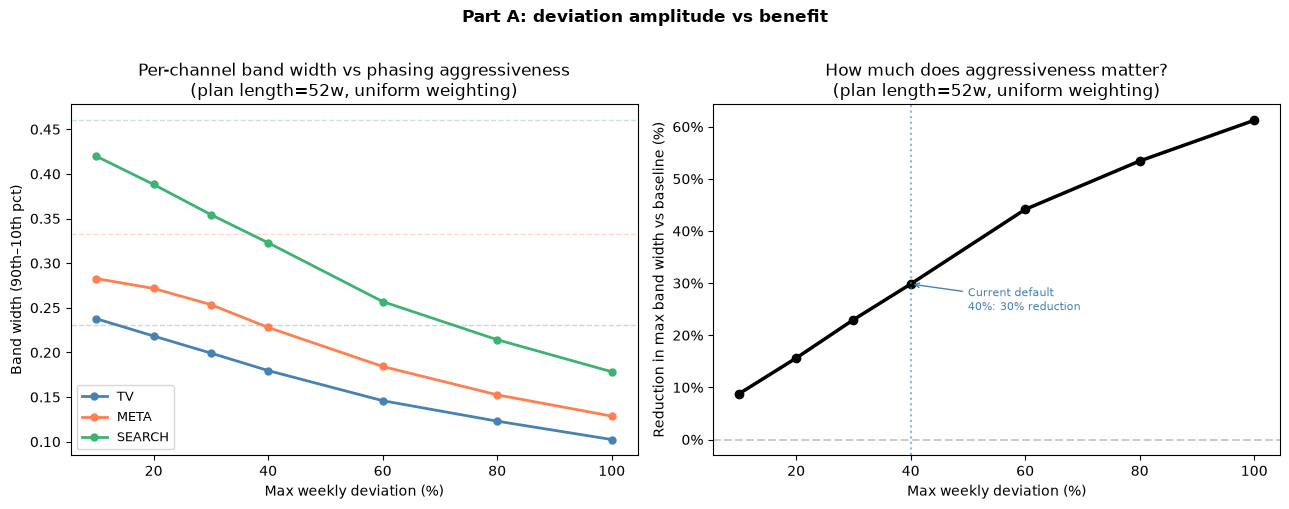


── Key findings ─────────────────────────────────────────────────────
  dev= 10%  |  reduction=+8.8%
  dev= 20%  |  reduction=+15.6%
  dev= 30%  |  reduction=+23.0%
  dev= 40%  |  reduction=+29.8%
  dev= 60%  |  reduction=+44.1%
  dev= 80%  |  reduction=+53.4%
  dev=100%  |  reduction=+61.2%

→ Marginal gain per 10pp increase in deviation falls from 6.9pp to 7.8pp — diminishing returns.


In [101]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: per-channel band width vs deviation
ax = axes[0]
for ch, color in COLORS.items():
    ax.plot(df_dev["dev_pct"], df_dev[ch], color=color, marker="o",
            linewidth=2, markersize=5, label=ch.upper())
    ax.axhline(baseline_bw[ch], color=color, linestyle="--", alpha=0.3, linewidth=1)
ax.set_xlabel("Max weekly deviation (%)")
ax.set_ylabel("Band width (90th\u201310th pct)")
ax.set_title("Per-channel band width vs phasing aggressiveness\n(plan length=52w, uniform weighting)")
ax.legend(fontsize=9)

# Right: % reduction vs deviation
ax2 = axes[1]
ax2.plot(df_dev["dev_pct"], df_dev["reduction_pct"], color="black",
         marker="o", linewidth=2.5, markersize=6)
ax2.axhline(0, color="gray", linestyle="--", alpha=0.4)

# Mark current default (40%)
r_40 = float(df_dev.loc[df_dev["dev_pct"] == 40, "reduction_pct"].iloc[0]) if 40 in df_dev["dev_pct"].values else None
if r_40:
    ax2.axvline(40, color="steelblue", linestyle=":", alpha=0.6)
    ax2.annotate(f"Current default\n40%: {r_40:.0f}% reduction",
                 xy=(40, r_40), xytext=(50, r_40 - 5),
                 fontsize=8, color="steelblue",
                 arrowprops=dict(arrowstyle="->", color="steelblue"))

ax2.set_xlabel("Max weekly deviation (%)")
ax2.set_ylabel("Reduction in max band width vs baseline (%)")
ax2.set_title("How much does aggressiveness matter?\n(plan length=52w, uniform weighting)")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))

plt.suptitle("Part A: deviation amplitude vs benefit", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("\n── Key findings ─────────────────────────────────────────────────────")
for _, row in df_dev.iterrows():
    print(f"  dev={int(row['dev_pct']):>3}%  |  reduction={row['reduction_pct']:+.1f}%")
marginal = df_dev["reduction_pct"].diff().dropna()
print(f"\n\u2192 Marginal gain per 10pp increase in deviation falls from "
      f"{marginal.iloc[0]:.1f}pp to {marginal.iloc[-1]:.1f}pp — diminishing returns.")

### Part B — Does higher deviation shift the time-to-benefit curve left?

Re-run the plan period sweep at three deviation levels. If the elbow shifts left at higher deviation, practitioners can reach the same benefit faster by accepting more weekly volatility.

In [102]:
deviation_levels = [20, 40, 80]
dev_colors = {20: "steelblue", 40: "black", 80: "coral"}

plan_lengths_s4 = (
    [4, 13, 26, 52, 104, 208]
    if FAST_MODE
    else [4, 8, 13, 26, 39, 52, 78, 104, 130, 156, 182, 208, 260]
)

sweep_by_dev = {}

for dev in deviation_levels:
    records = []
    for n_plan in plan_lengths_s4:
        plan_start = history.index[-1] + pd.Timedelta(weeks=1)
        plan_raw = simulate_spend(n_obs=n_plan, correlation=CORRELATION, seed=99)
        plan_raw.index = pd.date_range(plan_start, periods=n_plan, freq="W-MON")
        month_labels = _get_month_labels(plan_raw)
        weights = _compute_weights(
            n_history=N_HISTORY, n_plan=n_plan,
            weighting="uniform", plan_weight=1.0, half_life=52,
        )
        seed_bws = []
        for ps in range(N_PHASING_SEEDS):
            phased = _generate_phased_schedule(
                plan_raw, month_labels,
                alpha=1.0,
                max_weekly_deviation_pct=dev,
                seed=ps,
            )
            combined = pd.concat([history, phased])
            d = CollinearityDiagnostic(
                spend_df=combined,
                true_elasticities=TRUE_ELASTICITIES,
                weights=weights,
            )
            d.fit(n_sims=N_SIMS)
            seed_bws.append(band_width(d))
        bw = pd.concat(seed_bws, axis=1).mean(axis=1)
        reduction = (baseline_bw.max() - bw.max()) / baseline_bw.max() * 100
        records.append({"plan_weeks": n_plan, "max_bw": bw.max(), "reduction_pct": reduction})
        print(f"dev={dev}%  n_plan={n_plan:>3}w  |  reduction={reduction:+.1f}%")
    sweep_by_dev[dev] = pd.DataFrame(records)

dev=20%  n_plan=  4w  |  reduction=+4.8%
dev=20%  n_plan=  8w  |  reduction=-1.7%
dev=20%  n_plan= 13w  |  reduction=+7.1%
dev=20%  n_plan= 26w  |  reduction=+8.0%
dev=20%  n_plan= 39w  |  reduction=+22.9%
dev=20%  n_plan= 52w  |  reduction=+15.6%
dev=20%  n_plan= 78w  |  reduction=+32.5%
dev=20%  n_plan=104w  |  reduction=+32.3%
dev=20%  n_plan=130w  |  reduction=+42.8%
dev=20%  n_plan=156w  |  reduction=+39.8%
dev=20%  n_plan=182w  |  reduction=+46.3%
dev=20%  n_plan=208w  |  reduction=+36.4%
dev=20%  n_plan=260w  |  reduction=+51.4%
dev=40%  n_plan=  4w  |  reduction=+6.7%
dev=40%  n_plan=  8w  |  reduction=+7.6%
dev=40%  n_plan= 13w  |  reduction=+12.0%
dev=40%  n_plan= 26w  |  reduction=+17.5%
dev=40%  n_plan= 39w  |  reduction=+35.4%
dev=40%  n_plan= 52w  |  reduction=+29.8%
dev=40%  n_plan= 78w  |  reduction=+41.3%
dev=40%  n_plan=104w  |  reduction=+47.5%
dev=40%  n_plan=130w  |  reduction=+55.3%
dev=40%  n_plan=156w  |  reduction=+54.9%
dev=40%  n_plan=182w  |  reduction=+58.8

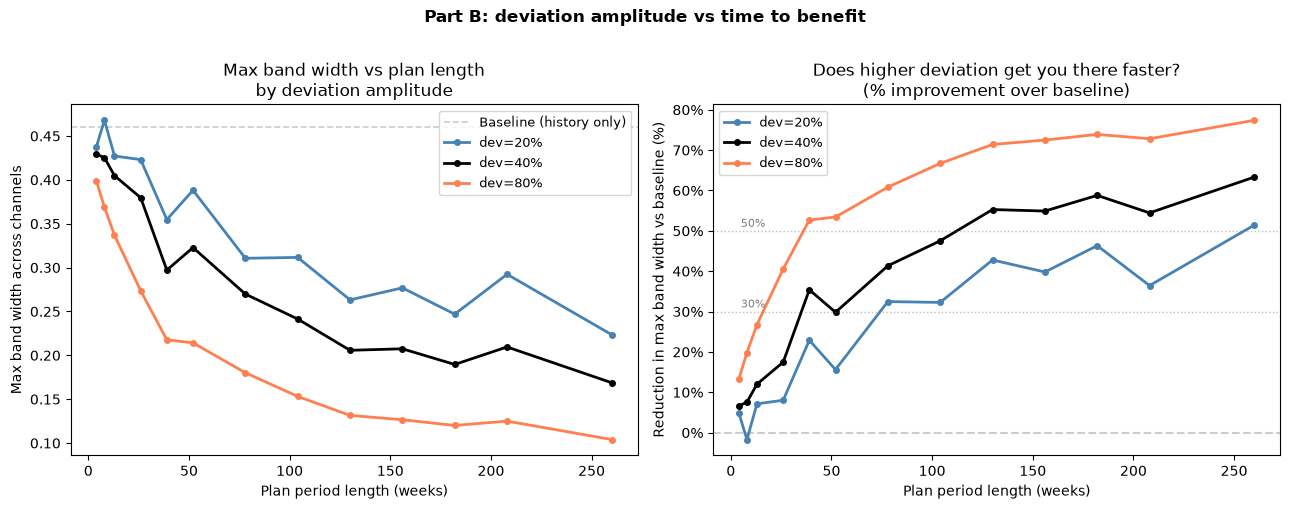


── Key findings ─────────────────────────────────────────────────────

Weeks to reach 20% reduction:
  dev=20%  →  39 weeks (0.8 years)
  dev=40%  →  39 weeks (0.8 years)
  dev=80%  →  13 weeks (0.2 years)

Weeks to reach 30% reduction:
  dev=20%  →  78 weeks (1.5 years)
  dev=40%  →  39 weeks (0.8 years)
  dev=80%  →  26 weeks (0.5 years)

Weeks to reach 50% reduction:
  dev=20%  →  260 weeks (5.0 years)
  dev=40%  →  130 weeks (2.5 years)
  dev=80%  →  39 weeks (0.8 years)


In [103]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: absolute band width by deviation level
ax = axes[0]
ax.axhline(baseline_bw.max(), color="gray", linestyle="--", alpha=0.4,
           linewidth=1.2, label="Baseline (history only)")
for dev, color in dev_colors.items():
    df = sweep_by_dev[dev]
    ax.plot(df["plan_weeks"], df["max_bw"], color=color, marker="o",
            linewidth=2, markersize=4, label=f"dev={dev}%")
ax.set_xlabel("Plan period length (weeks)")
ax.set_ylabel("Max band width across channels")
ax.set_title("Max band width vs plan length\nby deviation amplitude")
ax.legend(fontsize=9)

# Right: % reduction by deviation level
ax2 = axes[1]
ax2.axhline(0, color="gray", linestyle="--", alpha=0.4)
for dev, color in dev_colors.items():
    df = sweep_by_dev[dev]
    ax2.plot(df["plan_weeks"], df["reduction_pct"], color=color, marker="o",
             linewidth=2, markersize=4, label=f"dev={dev}%")

# Reference lines at 30% and 50% reduction
for ref, ls in [(30, ":"), (50, ":")]:
    ax2.axhline(ref, color="gray", linestyle=ls, alpha=0.5, linewidth=1)
    ax2.text(5, ref + 1, f"{ref}%", fontsize=8, color="gray")

ax2.set_xlabel("Plan period length (weeks)")
ax2.set_ylabel("Reduction in max band width vs baseline (%)")
ax2.set_title("Does higher deviation get you there faster?\n(% improvement over baseline)")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax2.legend(fontsize=9)

plt.suptitle("Part B: deviation amplitude vs time to benefit", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("\n── Key findings ─────────────────────────────────────────────────────")
for ref_pct in [20, 30, 50]:
    print(f"\nWeeks to reach {ref_pct}% reduction:")
    for dev in deviation_levels:
        df = sweep_by_dev[dev]
        hits = df[df["reduction_pct"] >= ref_pct]
        if not hits.empty:
            w = int(hits.iloc[0]["plan_weeks"])
            print(f"  dev={dev}%  \u2192  {w} weeks ({w/52:.1f} years)")
        else:
            print(f"  dev={dev}%  \u2192  not reached in this sweep")

### Part C — What does optimal phasing actually achieve, and what does it look like?

Two charts:
1. Per-channel band width: history-only baseline vs optimal phasing (dev=80%, 52 weeks, uniform). Shows residual uncertainty per channel.
2. Weekly spend time series: original plan vs phased plan at dev=80%. This is the actual prescription — the schedule handed to the media agency.

In [104]:
# ── Optimal config: dev=80%, 52 weeks, uniform weighting ─────────────────────
OPT_DEV = 80
OPT_PLAN_WEEKS = 52

plan_start = history.index[-1] + pd.Timedelta(weeks=1)
plan_opt = simulate_spend(n_obs=OPT_PLAN_WEEKS, correlation=CORRELATION, seed=99)
plan_opt.index = pd.date_range(plan_start, periods=OPT_PLAN_WEEKS, freq="W-MON")
month_labels_opt = _get_month_labels(plan_opt)

weights_opt = _compute_weights(
    n_history=N_HISTORY, n_plan=OPT_PLAN_WEEKS,
    weighting="uniform", plan_weight=1.0, half_life=52,
)

# Average over phasing seeds for stability
seed_bws_opt = []
phased_opt_example = None  # keep one for plotting
for ps in range(N_PHASING_SEEDS):
    phased = _generate_phased_schedule(
        plan_opt, month_labels_opt,
        alpha=1.0,
        max_weekly_deviation_pct=OPT_DEV,
        seed=ps,
    )
    if ps == 0:
        phased_opt_example = phased  # save seed=0 for the time series plot
    combined = pd.concat([history, phased])
    d = CollinearityDiagnostic(
        spend_df=combined,
        true_elasticities=TRUE_ELASTICITIES,
        weights=weights_opt,
    )
    d.fit(n_sims=N_SIMS)
    seed_bws_opt.append(band_width(d))

bw_opt = pd.concat(seed_bws_opt, axis=1).mean(axis=1)

print("Per-channel band width comparison:")
print(f"{'Channel':<10} {'Baseline':>10} {'Optimal':>10} {'Reduction':>12}")
for ch in TRUE_ELASTICITIES:
    base = baseline_bw[ch]
    opt  = bw_opt[ch]
    red  = (base - opt) / base * 100
    print(f"{ch:<10} {base:>10.3f} {opt:>10.3f} {red:>11.1f}%")

Per-channel band width comparison:
Channel      Baseline    Optimal    Reduction
tv              0.231      0.123        46.8%
meta            0.333      0.152        54.2%
search          0.460      0.214        53.4%


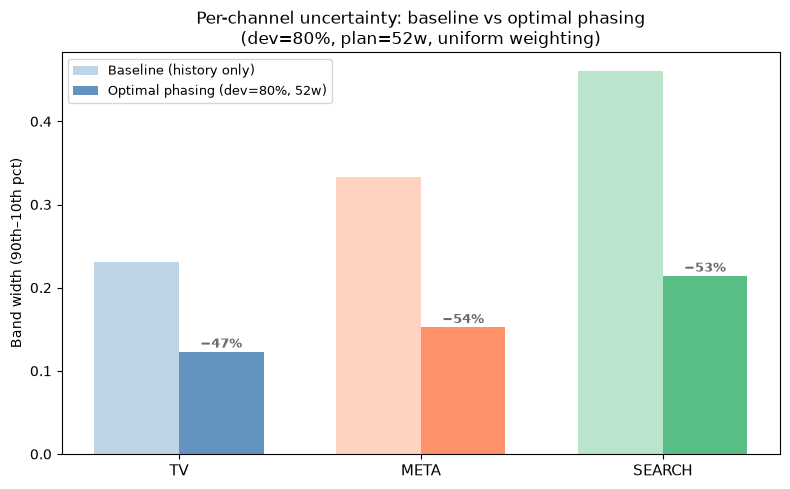

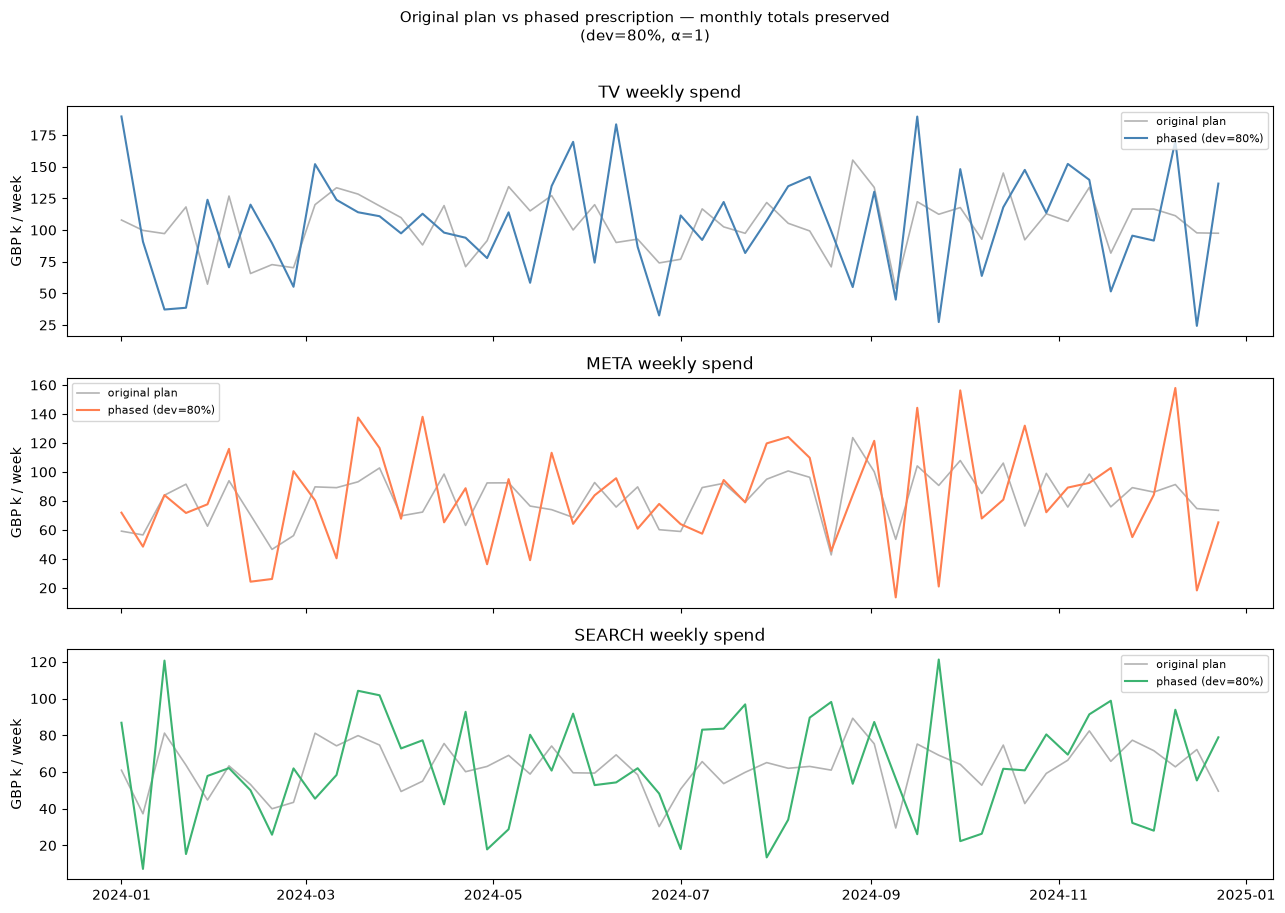

In [105]:
fig, ax = plt.subplots(figsize=(8, 5))
channels = list(TRUE_ELASTICITIES.keys())
x = np.arange(len(channels))
width = 0.35

ax.bar(x - width/2, [baseline_bw[ch] for ch in channels],
       width, color=[COLORS[ch] for ch in channels],
       alpha=0.35, label="Baseline (history only)")
ax.bar(x + width/2, [bw_opt[ch] for ch in channels],
       width, color=[COLORS[ch] for ch in channels],
       alpha=0.85, label=f"Optimal phasing (dev={OPT_DEV}%, {OPT_PLAN_WEEKS}w)")

for i, ch in enumerate(channels):
    base = baseline_bw[ch]
    opt  = bw_opt[ch]
    red  = (base - opt) / base * 100
    ax.text(i + width/2, opt + 0.005, f"\u2212{red:.0f}%",
            ha="center", fontsize=9, color="dimgray", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([ch.upper() for ch in channels], fontsize=11)
ax.set_ylabel("Band width (90th\u201310th pct)")
ax.set_title(f"Per-channel uncertainty: baseline vs optimal phasing\n"
             f"(dev={OPT_DEV}%, plan={OPT_PLAN_WEEKS}w, uniform weighting)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── Weekly spend: stacked subplots, one per channel ───────────────────────────
fig2, axes2 = plt.subplots(len(channels), 1, figsize=(13, 9), sharex=True)

for ax2, ch in zip(axes2, channels):
    color = COLORS[ch]
    ax2.plot(plan_opt.index, plan_opt[ch] / 1_000,
             color="grey", alpha=0.6, linewidth=1.2, label="original plan")
    ax2.plot(phased_opt_example.index, phased_opt_example[ch] / 1_000,
             color=color, linewidth=1.5, label=f"phased (dev={OPT_DEV}%)")
    ax2.set_ylabel("GBP k / week")
    ax2.set_title(f"{ch.upper()} weekly spend")
    ax2.legend(fontsize=8)

plt.suptitle(
    f"Original plan vs phased prescription — monthly totals preserved\n"
    f"(dev={OPT_DEV}%, \u03b1=1)",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.show()